In [1]:
import torch

from occhio import ToyModel
from occhio.autoencoder import TiedLinearRelu
from occhio.distributions import CorrelatedPairs
from occhio.model_grid import ModelGrid, Axis, TrainingAxis
from occhio.visualization import (
    plot_embedding,
    plot_phase_change,
    plot_geometry,
    plot_feature_geometry,
    plot_feature_geometry_3d,
    plot_representation,
)

In [2]:
device = "cpu"

In [3]:
N_FEATURES = 20
N_HIDDEN = 5

In [4]:
def create_model(params):
    generator = torch.Generator(device=device).manual_seed(199)

    return ToyModel(
        ae=TiedLinearRelu(N_FEATURES, N_HIDDEN, device=device, generator=generator),
        distribution=CorrelatedPairs(
            N_FEATURES,
            density=params["Density"],
            correlation=0.0,
            device=device,
            generator=generator,
        ),
        # Correlated pairs of diminishing importance, where within the second feature is also less important.
        importances=torch.tensor([1, 0.7] * int(N_FEATURES / 2))
        * (0.9 ** torch.arange(N_FEATURES)),
        device=device,
    )


grid = ModelGrid(
    create_model,
    axes=[Axis(label="Density", values=[1])], #, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001])],
)

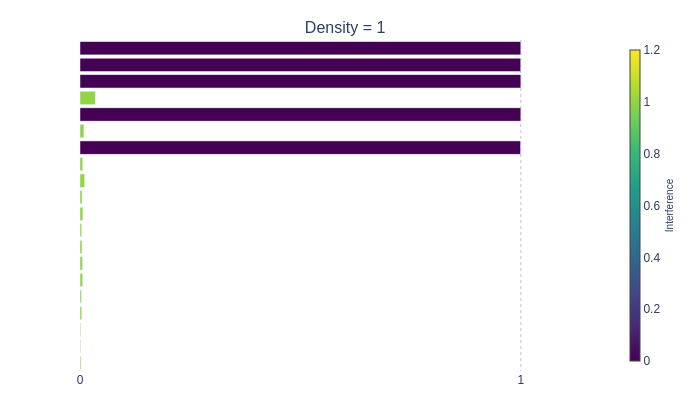

In [5]:
grid.fit(50000)

import sys                                                                                  
sys.path.insert(0, "..")                                                                    
from custom.plotting import plot_bars                                                       
                                                                                          
plot_bars(grid)